# APTOS ben_graham

In [1]:
import os
import random
import shutil
import cv2
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from concurrent.futures import ThreadPoolExecutor, as_completed
import matplotlib.pyplot as plt

cv2.setNumThreads(0)

# Configurari
APTOS_DIR = Path(r"B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\originals\aptos_normal")
CSVS = [APTOS_DIR / "train_1.csv", APTOS_DIR / "valid.csv", APTOS_DIR / "test.csv"]
IMG_FOLDERS = [APTOS_DIR / "train_images", APTOS_DIR / "val_images", APTOS_DIR / "test_images"]

OUTPUT_DIR = Path(r"B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\processed_by_me\aptos\aptos_augmented_bengraham")
CLASSES = [0, 1, 2, 3, 4]
WORKERS = max((os.cpu_count() or 2) - 1, 1)

RATIO_TRAIN, RATIO_VAL, RATIO_TEST = 0.70, 0.20, 0.10

## Impartirea datelor (70/20/10)

In [2]:
def get_image_path(img_id):
    for folder in IMG_FOLDERS:
        if not folder.exists(): continue
        for ext in ['.png', '.jpg', '.jpeg']:
            p = folder / f"{img_id}{ext}"
            if p.exists(): return p
    return None

valid_csvs = [csv for csv in CSVS if csv.exists()]
df = pd.concat([pd.read_csv(csv) for csv in valid_csvs], ignore_index=True)

# Auto-detectare coloane
img_col, lbl_col = ('id_code', 'diagnosis') if 'id_code' in df.columns else (df.columns[0], df.columns[1])

valid_data = []
for _, row in tqdm(df.iterrows(), total=len(df), desc="Verificare fisiere"):
    img_path = get_image_path(str(row[img_col]))
    if img_path:
        valid_data.append({'path': img_path, 'label': int(row[lbl_col]), 'id': str(row[img_col])})

df_valid = pd.DataFrame(valid_data)
print(f"Total imagini valide: {len(df_valid)}")

# Impartire Stratificata
df_train_val, df_test = train_test_split(df_valid, test_size=RATIO_TEST, stratify=df_valid['label'], random_state=42)
val_fraction = RATIO_VAL / (RATIO_TRAIN + RATIO_VAL)
df_train, df_val = train_test_split(df_train_val, test_size=val_fraction, stratify=df_train_val['label'], random_state=42)

print(f"TRAIN: {len(df_train)} | VAL: {len(df_val)} | TEST: {len(df_test)}")

Verificare fisiere:   0%|          | 0/3662 [00:00<?, ?it/s]

Total imagini valide: 3662
TRAIN: 2562 | VAL: 733 | TEST: 367


## Aplicare ben_graham si salvare train/test/val

In [3]:
if OUTPUT_DIR.exists(): shutil.rmtree(OUTPUT_DIR)
for split in ['train', 'val', 'test']:
    for cls in CLASSES:
        (OUTPUT_DIR / split / str(cls)).mkdir(parents=True, exist_ok=True)

def procesare_ben_graham_elipsa_halo(image_path, size=512):
    img = cv2.imread(str(image_path))
    img_resized = cv2.resize(img, (size, size))
    gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)

    _, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    kernel_clean = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    thresh_clean = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel_clean)
    
    contours, _ = cv2.findContours(thresh_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours: return img_resized

    contur_ochi = max(contours, key=cv2.contourArea)
    masca_ochi = np.zeros((size, size), dtype=np.uint8)
    cv2.drawContours(masca_ochi, [contur_ochi], -1, 255, thickness=cv2.FILLED)
    masca_ochi = cv2.erode(masca_ochi, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11)), iterations=1)

    blur = cv2.GaussianBlur(gray, (0, 0), size / 30.0)
    ben_graham_gray = cv2.addWeighted(gray, 4, blur, -4, 128)

    masca_exterior = cv2.bitwise_not(masca_ochi)
    dist = cv2.distanceTransform(masca_exterior, cv2.DIST_L2, 5)
    
    rezultat_final = np.full((size, size), 128.0, dtype=np.float32)
    halo_mask = (dist > 0) & (dist <= 35.0)
    rezultat_final[halo_mask] = 128.0 * (dist[halo_mask] / 35.0)

    interior_mask = (masca_ochi == 255)
    rezultat_final[interior_mask] = ben_graham_gray[interior_mask]
    
    # Convertim inapoi in format cu 3 canale pentru compatibilitate cu modelele CNN
    return cv2.cvtColor(rezultat_final.astype(np.uint8), cv2.COLOR_GRAY2BGR)

def process_and_copy(task):
    src, dst = task
    try:
        processed = procesare_ben_graham_elipsa_halo(src)
        cv2.imwrite(str(dst), processed)
        return True
    except: return False

tasks = []
for df_split, split_name in [(df_train, 'train'), (df_val, 'val'), (df_test, 'test')]:
    for _, row in df_split.iterrows():
        dst = OUTPUT_DIR / split_name / str(row['label']) / f"{row['id']}.png"
        tasks.append((row['path'], dst))

with ThreadPoolExecutor(max_workers=WORKERS) as executor:
    for _ in tqdm(executor.map(process_and_copy, tasks), total=len(tasks), desc="Procesare Ben Graham"): pass
print("Imaginile au fost procesate Ben Graham si impartite!")

Procesare Ben Graham:   0%|          | 0/3662 [00:00<?, ?it/s]

Imaginile au fost procesate Ben Graham si impartite!


In [4]:
# Print cate imagini avem pe fiecare split si pe fiecare classa
print("\n--- 3. Verificare distributie finala ---")
for split in ['train', 'val', 'test']:
    print(f"\nSplit: {split.upper()}")
    for cls in CLASSES:
        count = len(list((OUTPUT_DIR / split / str(cls)).glob("*.*")))
        print(f"  Clasa {cls}: {count} imagini")


--- 3. Verificare distributie finala ---

Split: TRAIN
  Clasa 0: 1263 imagini
  Clasa 1: 259 imagini
  Clasa 2: 699 imagini
  Clasa 3: 135 imagini
  Clasa 4: 206 imagini

Split: VAL
  Clasa 0: 361 imagini
  Clasa 1: 74 imagini
  Clasa 2: 200 imagini
  Clasa 3: 39 imagini
  Clasa 4: 59 imagini

Split: TEST
  Clasa 0: 181 imagini
  Clasa 1: 37 imagini
  Clasa 2: 100 imagini
  Clasa 3: 19 imagini
  Clasa 4: 30 imagini


## Augmentarea DOAR pe Train (Echilibrare)

In [5]:
def apply_flip(img, rng):
    if rng.random() < 0.5: img = cv2.flip(img, 1)
    if rng.random() < 0.5: img = cv2.flip(img, 0)
    return img

def apply_color_jitter(img, rng):
    return cv2.convertScaleAbs(img, alpha=rng.uniform(0.85, 1.15), beta=rng.uniform(-10, 10))

def apply_blur(img, rng): 
    return cv2.GaussianBlur(img, rng.choice([(3,3), (5,5)]), rng.uniform(0.3, 1.2))

def apply_affine_bg(img, rng):
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w/2, h/2), rng.uniform(-45, 45), rng.uniform(0.85, 1.15))
    # Aici folosim 128 pentru a pastra culoarea de background specifica Ben Graham
    return cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_CONSTANT, borderValue=(128,128,128))

def augment_image_bg(task):
    src, dst_dir, idx, seed = task
    rng = random.Random(seed)
    img = cv2.imread(str(src))
    
    ops = [(apply_flip, "flip"), (apply_affine_bg, "affine"), (apply_color_jitter, "color")]
    if rng.random() < 0.5: ops.append((apply_blur, "blur"))
        
    chosen = rng.sample(ops, rng.randint(2, len(ops)))
    names = []
    for op_func, name in chosen:
        img = op_func(img, rng)
        names.append(f"aug_{name}")
        
    new_name = f"{src.stem}_{idx:03d}_{'_'.join(names)}{src.suffix}"
    cv2.imwrite(str(dst_dir / new_name), img)

train_dir = OUTPUT_DIR / 'train'
max_count = max(len(list((train_dir / str(c)).glob('*.png'))) for c in CLASSES)
print(f"Target de echilibrare pe Train (Ben Graham): {max_count} imagini/clasa")

aug_tasks = []
rng = random.Random(42)

for cls in CLASSES:
    cls_dir = train_dir / str(cls)
    originals = sorted(list(cls_dir.glob('*.png')))
    missing = max_count - len(originals)
    
    if missing > 0:
        for i in range(missing):
            src = originals[i % len(originals)]
            aug_tasks.append((src, cls_dir, i+1, rng.randint(0, 999999)))

with ThreadPoolExecutor(max_workers=WORKERS) as executor:
    for _ in tqdm(executor.map(augment_image_bg, aug_tasks), total=len(aug_tasks), desc="Augmentare Train (BG)"): pass
print("Datasetul Ben Graham este echilibrat si gata de antrenament!")

Target de echilibrare pe Train (Ben Graham): 1263 imagini/clasa


Augmentare Train (BG):   0%|          | 0/3753 [00:00<?, ?it/s]

Datasetul Ben Graham este echilibrat si gata de antrenament!


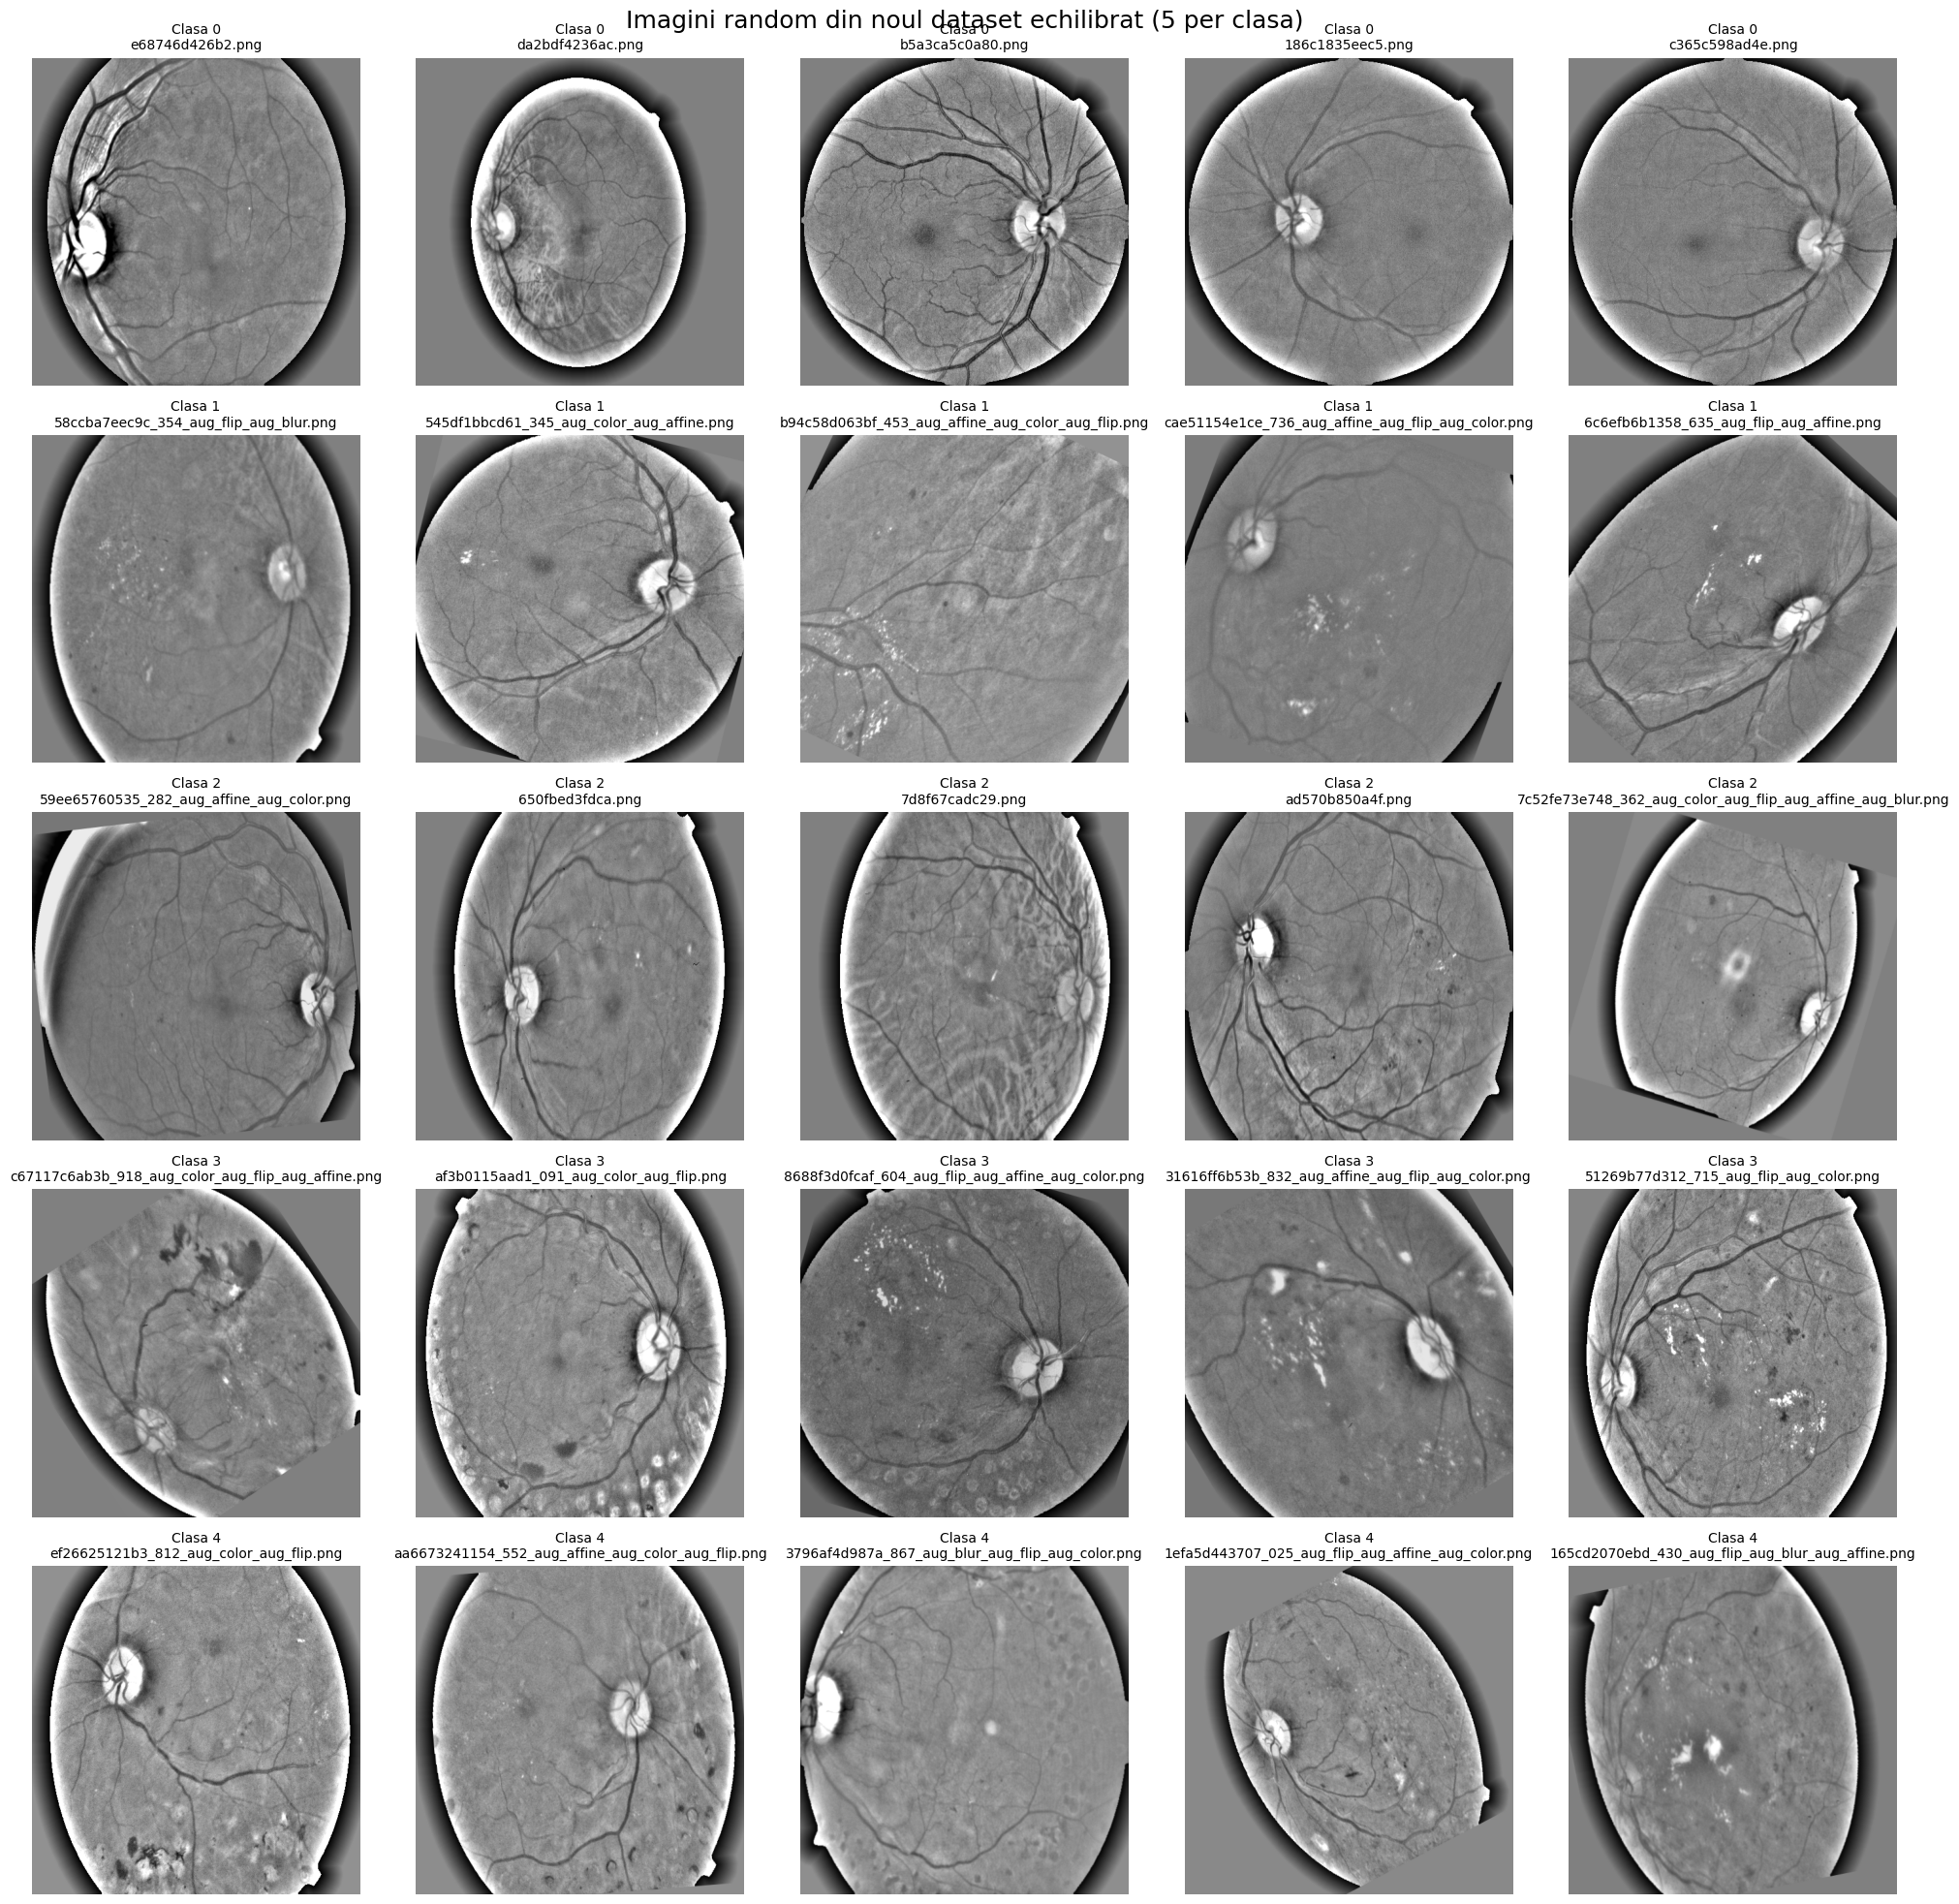

In [7]:
# Show images from the new dataset (5 random images from each class, in a 5x5 grid)
def arata_imagini_random_din_dataset(cale_dataset):
    classes = ["0", "1", "2", "3", "4"]
    extensii_imagini = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

    fig, axes = plt.subplots(5, 5, figsize=(20, 20))
    fig.suptitle("Imagini random din noul dataset echilibrat (5 per clasa)", fontsize=18)

    for row, cls in enumerate(classes):
        folder_cls = Path(cale_dataset) / cls
        imagini_cls = [f for f in folder_cls.iterdir() if f.is_file() and f.suffix.lower() in extensii_imagini]
        
        if len(imagini_cls) < 5:
            print(f"Atentie: Clasa {cls} are doar {len(imagini_cls)} imagini. Se vor afisa toate.")
            selected_images = imagini_cls
        else:
            selected_images = random.sample(imagini_cls, 5)
        
        for col, img_path in enumerate(selected_images):
            img = cv2.imread(str(img_path))
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[row, col].imshow(img_rgb)
            axes[row, col].set_title(f"Clasa {cls}\n{img_path.name}", fontsize=10)
            axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()

arata_imagini_random_din_dataset(r"B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\processed_by_me\aptos\aptos_augmented_bengraham\train")